In [1]:
from IPython.display import clear_output
from bs4 import BeautifulSoup
import requests
from datetime import datetime
import time
import re
import sys
#import unicodecsv as csv
#import html2text
from __future__ import division
import nltk
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.corpus import stopwords
import pickle
import pandas as pd
from spacy.tokenizer import Tokenizer
import spacy
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.stem.snowball import SnowballStemmer
import zipfile
import gensim
from pathlib import Path
import csv
import os
from gensim.models import Phrases
from gensim.models.phrases import Phraser

stemmer = SnowballStemmer("english")
nltk.download('stopwords')
stopwords = set(stopwords.words('english'))
Tokenizer = spacy.load('en_core_web_sm').tokenizer
#path = "G:\\My Drive\\Work\\Working Papers\\evidence in legislatures_Barak-Corren&Ash"
path = "C:\\Users\\mitha\\Documents\\empirical_evidence_corren"

# Set the project root directory
PROJECT_ROOT = Path(path)

# Function to construct paths relative to the project root
def project_path(*args):
    return PROJECT_ROOT.joinpath(*args)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mitha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [16]:
#df = pd.read_pickle(project_path("data","merged_hearings.pkl"))

In [50]:
hearing_list = [
    f[:-4] for f in os.listdir(project_path("data"))
    if f.startswith("CHRG") and f.endswith(".csv") and "_sentcontext" not in f
]

# Initialize an empty list to hold DataFrames
dfs = []

# Load each file and append its DataFrame to the list
for file_name in hearing_list:
    file_path = os.path.join(project_path("data"), f"{file_name}.csv")
    df = pd.read_csv(file_path)
    dfs.append(df)

# Merge all DataFrames into one
merged_df = pd.concat(dfs, ignore_index=True)

In [54]:
from gensim.models import Phrases
from gensim.models.phrases import Phraser

documents = merged_df['speech']

sentence_stream = [doc.split(" ") for doc in documents]
bigram = Phrases(sentence_stream, min_count=1, threshold=2)

# Convert to a Phraser
bigram_phraser = Phraser(bigram)

# Save the Phraser
bigram_phraser.save(str(project_path("scripts", "con_dicts", "bigram_phraser.pkl")))

In [125]:
bigram = Phraser.load(str(project_path("scripts", "con_dicts", "bigram_phraser.pkl")))

dont_stem = ['constitute', 'constituting', 'constitutes', 'takings', 'presentment', 'originalism', 'originalist',
            'federalism']

def preprocess_wsw(text):
    '''A function that tokenizes a sentence'''
    text = text.lower()
    text = re.sub('-', ' ', text)
    text = re.sub('[^A-Za-z0-9 ]', '', text)
    text = re.sub(r'\s+', ' ', text)
    tokenized = Tokenizer(text)
    tokens = (t.text for t in tokenized)
    #tokens = (w for w in tokens if not w in stopwords and len(w) > 1 and w != '')
    new_tokens = []
    for w in tokens:
        if w in dont_stem:
            new_tokens.append(w)
        else:
            new_tokens.append(stemmer.stem(w))
    #tokens = [stemmer.stem(w) for w in tokens if w not in dont_stem ]
    all_text = (' ').join(new_tokens)
    all_text = re.sub(r'\s+', ' ', all_text)
    return all_text

def create_dict(MAX):
    all_con_dicts = []
    con_dict_trans = {}
    for i in range(1,MAX):
        con_dict_new = []
        with open(project_path("scripts", "con_dicts") / f"dict_{i}.csv", 'r', encoding="ISO-8859-1") as inputfile:
            for row in csv.reader(inputfile, delimiter = ','):
                term_original = row[0].strip() # remove leading and trailing spaces
                term = (' ').join(bigram[term_original.split(' ')])
                term = preprocess_wsw(term)
                if term != '':
                    con_dict_new.append(' ' + term + ' ')
                    con_dict_trans[' ' + term + ' '] = term_original
        all_con_dicts.append(con_dict_new)
        
    all_con_dicts = [list(set(the_dict)) for the_dict in all_con_dicts]
    
    the_con_dict = []
    for con_dict in all_con_dicts:
        for term in con_dict:
            the_con_dict.append(term)
    the_con_dict = list(set(the_con_dict))
    return the_con_dict, all_con_dicts, con_dict_trans

#### 
cnrs = [str(x).zfill(3) for x in range(105, 114)]


# Modified process_hearings function
def process_hearings(hearing_list):
    counter = 0
    result_dict = {}  # Dictionary to store results, indexed by file name
    all_rel_frequencies = []  # List to store all 'all_rel' values for density plot
    
    for file_name in hearing_list:
        # Subset the DataFrame to only include rows from the current file
        temp_df = main_df[main_df['file_name'] == file_name + ".txt"]

        print(f"Processing hearing: {file_name}")
        # Combine all speeches into one large string
        speeches = " ".join(temp_df['speech'].dropna())
        
        # Total number of words in the combined speeches
        all_nwords = len(speeches.split())
        
        all_terms = []  # List to store term-related dictionaries
        
        # Iterate through the terms in the_con_dict
        for term in the_con_dict:
            my_dict = {}
            my_dict['term'] = con_dict_trans[term]  # Transformed term
            
            # Count occurrences of the term in speeches
            term_count = speeches.count(term)
            
            # Populate the dictionary with counts and relative frequency
            my_dict['all_total'] = term_count
            my_dict['all_rel'] = round(term_count / all_nwords * 1000000, 3)
            
            # Add the term's dictionary to the list
            all_terms.append(my_dict)
            
            # Save 'all_rel' to the frequency list for density plotting (no filtering)
            all_rel_frequencies.append(my_dict['all_rel'])
        
        # Sort the terms by their relative frequency in descending order
        all_terms = sorted(all_terms, key=lambda k: k['all_rel'], reverse=True)
        
        # Add the sorted terms to the result dictionary indexed by the file name
        result_dict[file_name] = all_terms

        counter += 1
        print(f"Done with hearing: {file_name}. {counter} out of {len(hearing_list)}")
    
    return result_dict, all_rel_frequencies

In [203]:
df_freq_con = pd.read_pickle(project_path("scripts","con_dicts","df_freq_con.pkl"))

In [205]:
the_con_dict, all_con_dicts, con_dict_trans = create_dict(6)
all_con_dicts = [[item.strip() for item in sublist] for sublist in all_con_dicts]

versions = [sum(all_con_dicts[:i+1], []) for i in range(len(all_con_dicts))]

In [207]:
# Function to calculate average frequency
def calculate_average_frequency(df, term_columns):
    """Add a column with the average relative frequency for the provided term columns."""
    # Compute the average relative frequency for each row
    df['average_freq_temp'] = df[term_columns].apply(
        lambda row: sum(freq for _, freq in row if isinstance(freq, (int, float))) / len(term_columns), axis=1
    )
    return df['average_freq_temp']

In [209]:
# Process each version
for i, version in enumerate(versions, 1):
    # Identify columns matching the current version's terms
    term_columns = [col for col in df_freq_con.columns if any(term in col for term in version)]
    
    # Calculate the average frequency for the matched columns
    df_freq_con[f'average_freq_ver{i}'] = calculate_average_frequency(df_freq_con, term_columns)

# Drop the temporary column
df_freq_con = df_freq_con.drop(columns=['average_freq_temp'])

In [233]:
df_freq_con['average_freq_ver4'].mean()

0.10030851561722044

In [272]:
df_freq_con['class_const'] = (df_freq_con['average_freq_ver5'] > 0).astype(int)

In [274]:
df_freq_con.to_csv(project_path("data","df_freq_con.csv"), index=False)

average_freq_ver1 - Mean: 0.0
average_freq_ver1 - Unique values: [0.]

average_freq_ver2 - Mean: 0.005281728360043494
average_freq_ver2 - Unique values: [0.         2.12101515 1.63042424 4.05554545 1.1835303  1.73259091
 2.42928788 1.51515152 4.91134848 0.28124242]

average_freq_ver3 - Mean: 0.022337115216315973
average_freq_ver3 - Unique values: [0.         1.23984146 1.70715854 1.31229268 3.26421951 1.6329878
 1.12067073 2.05754878 1.23170732 0.95259756]

average_freq_ver4 - Mean: 0.10030851561722044
average_freq_ver4 - Unique values: [0.         0.50292553 1.34423404 0.70648936 0.95376596 0.65575532
 1.90941489 1.08156383 1.41259574 2.62544681]

average_freq_ver5 - Mean: 0.6206838301760642
average_freq_ver5 - Unique values: [0.39454857 0.         1.45032571 1.41688    0.71778286 1.48230286
 0.88442857 2.49968571 1.89098286 1.09742286]

average_freq_ver1: {'rate_greater_than_zero': 0.0, 'rate_greater_than_mean': 0.0}
average_freq_ver2: {'rate_greater_than_zero': 0.0021060842433697348

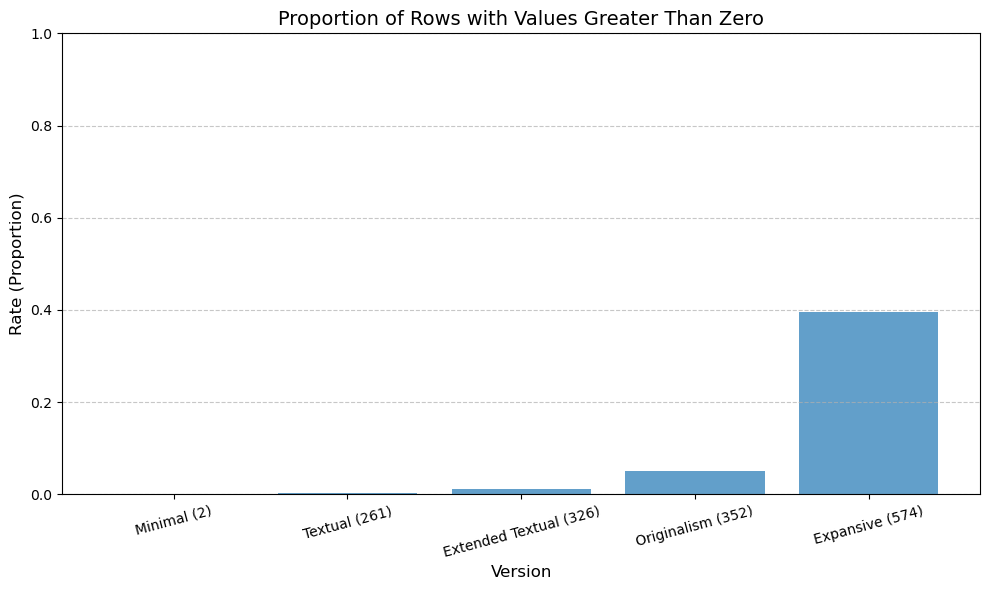

In [263]:
# Debugging: Check mean values and unique values
for i in range(1, len(versions) + 1):
    column = f'average_freq_ver{i}'
    mean_value = df_freq_con[column].mean()
    print(f"{column} - Mean: {mean_value}")
    print(f"{column} - Unique values: {df_freq_con[column].unique()[:10]}")
    print()

# Correct rate calculations
rates = {}
for i in range(1, len(versions) + 1):
    column = f'average_freq_ver{i}'
    mean_value = df_freq_con[column].mean()

    # Calculate rates
    rate_greater_than_zero = (df_freq_con[column] > 0).mean()
    rate_greater_than_mean = (df_freq_con[column] > mean_value).mean()

    rates[column] = {
        'rate_greater_than_zero': rate_greater_than_zero,
        'rate_greater_than_mean': rate_greater_than_mean,
    }

# Print rates
for column, metrics in rates.items():
    print(f"{column}: {metrics}")

# Visualize density plots
import matplotlib.pyplot as plt

# Custom version names and lengths
custom_names = ["Minimal", "Textual", "Extended Textual", "Originalism", "Expansive"]
lengths = [len(versions[i - 1]) for i in range(1, len(versions) + 1)]  # Calculate lengths
x_labels = [f"{name} ({length})" for name, length in zip(custom_names, lengths)]  # Combine names and lengths

# Prepare data for bar plot
rates_greater_than_zero = [rates[f'average_freq_ver{i}']['rate_greater_than_zero'] for i in range(1, len(versions) + 1)]

# Create bar plot
plt.figure(figsize=(10, 6))
plt.bar(x_labels, rates_greater_than_zero, alpha=0.7)

# Add labels and title
plt.title('Proportion of Rows with Values Greater Than Zero', fontsize=14)
plt.xlabel('Version', fontsize=12)
plt.ylabel('Rate (Proportion)', fontsize=12)
plt.ylim(0, 1)  # Proportions are between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(fontsize=10, rotation=15)  # Rotate labels for better visibility
plt.yticks(fontsize=10)

# Show plot
plt.tight_layout()

plt.savefig(project_path("plots","dictionary_proportions.png"), dpi=300)  # Save as PNG with high resolution
plt.show()

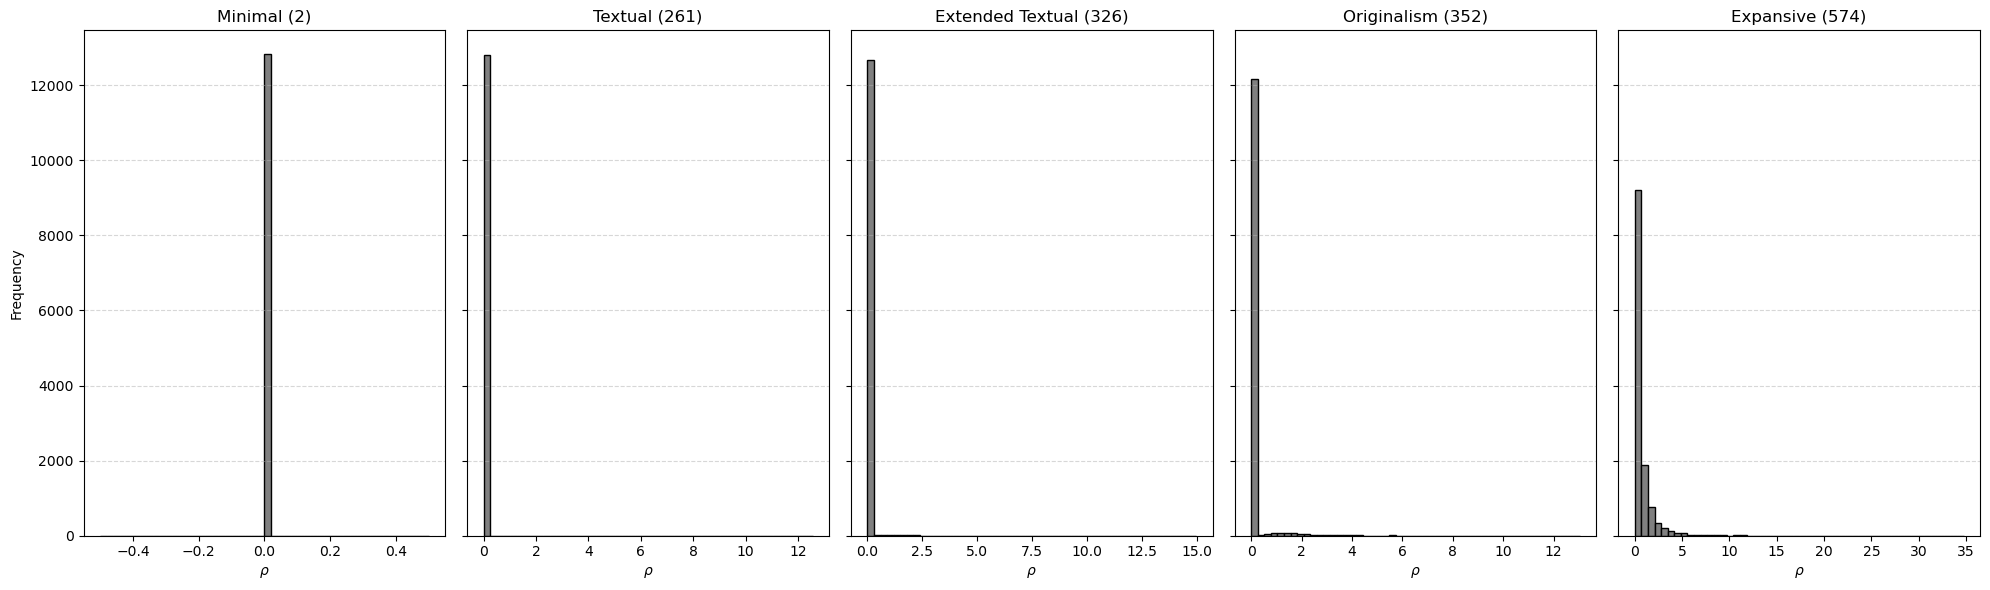

In [260]:
import matplotlib.pyplot as plt

# Example data: Replace these with your actual data
data_columns = [f'average_freq_ver{i}' for i in range(1, 6)]
#version_names = ["Minimal (2)", "Textual (4)", "Extended Textual (6)", "Originalism (8)", "Expansive (10)"]


custom_names = ["Minimal", "Textual", "Extended Textual", "Originalism", "Expansive"]
lengths = [len(versions[i - 1]) for i in range(1, len(versions) + 1)]  # Calculate lengths
version_names = [f"{name} ({length})" for name, length in zip(custom_names, lengths)]  # Combine names and lengths

# Set up the figure and subplots
fig, axes = plt.subplots(1, 5, figsize=(20, 6), sharey=True)  # 5 subplots side-by-side

# Loop through each version to create the plots
for i, ax in enumerate(axes):
    column = data_columns[i]
    version_name = version_names[i]
    
    # Plot histogram for the current version
    axes[i].hist(df_freq_con[column], bins=50, color='gray', edgecolor='black')
    axes[i].set_title(version_name, fontsize=12)
    axes[i].set_xlabel(r'$\rho$', fontsize=10)  # Symbol for rho
    if i == 0:
        axes[i].set_ylabel("Frequency", fontsize=10)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

# Adjust layout and display
plt.tight_layout()

plt.savefig(project_path("plots","frequency_distributions.png"), dpi=300)  # Save as PNG with high resolution
plt.show()

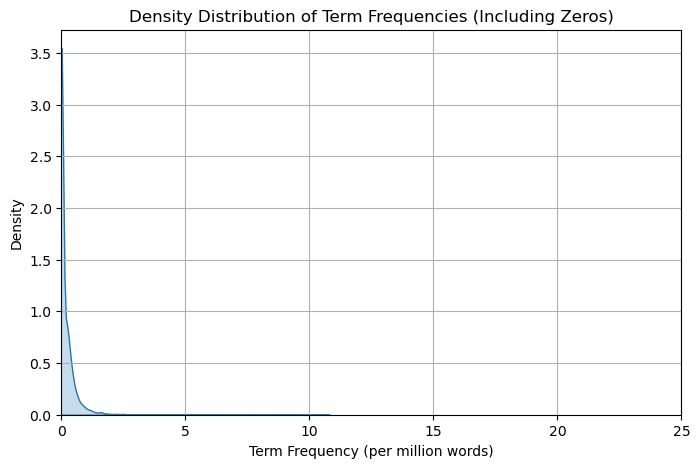

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the density distribution
plt.figure(figsize=(8, 5))
sns.kdeplot(df_freq_con['average_freq'], fill=True)
plt.title('Density Distribution of Term Frequencies (Including Zeros)')
plt.xlabel('Term Frequency (per million words)')
plt.ylabel('Density')
plt.xlim(0, 25)  # Set x-axis limits between 0 and 200
plt.grid(True)
plt.show()

In [300]:
def evaluate_dict(result_dict):
    non_zero_file_count = 0  # Counter for files with non-zero terms
    
    for file_name, terms in result_dict.items():
        # Filter terms with non-zero relative frequency
        non_zero_terms = [term for term in terms if term['all_rel'] > 0]
        
        if non_zero_terms:  # If there are terms with non-zero frequency
            non_zero_file_count += 1  # Increment the counter
            print(f"File: {file_name}")
            for term in non_zero_terms:
                print(f"  Term: {term['term']}, Total Count: {term['all_total']}, Frequency (per million): {term['all_rel']}")
            print()  # Add a blank line for better readability
    
    # Print the total number of files with non-zero terms
    print(f"Total number of files with non-zero terms: {non_zero_file_count}")
    print(f"Share of files with non-zero terms: {round(non_zero_file_count/len(hearing_list),2)}")


for i in range(1,7):
    print(f'Con dictionary number: {i}')
    the_con_dict, all_con_dicts, con_dict_trans = create_dict(i)
    print(f'Length of Con dictionary: {len(the_con_dict)}')
    result_dict = process_hearings(hearing_list)
    evaluate_dict(result_dict)
    print()

Con dictionary number: 1
Length of Con dictionary: 0
Share of files with non-zero terms: 0.0

Con dictionary number: 2
Length of Con dictionary: 2
Share of files with non-zero terms: 0.0

Con dictionary number: 3
Length of Con dictionary: 258
Share of files with non-zero terms: 0.01

Con dictionary number: 4
Length of Con dictionary: 324
Share of files with non-zero terms: 0.01

Con dictionary number: 5
Length of Con dictionary: 350
Share of files with non-zero terms: 0.07

Con dictionary number: 6
Length of Con dictionary: 555
Share of files with non-zero terms: 0.38



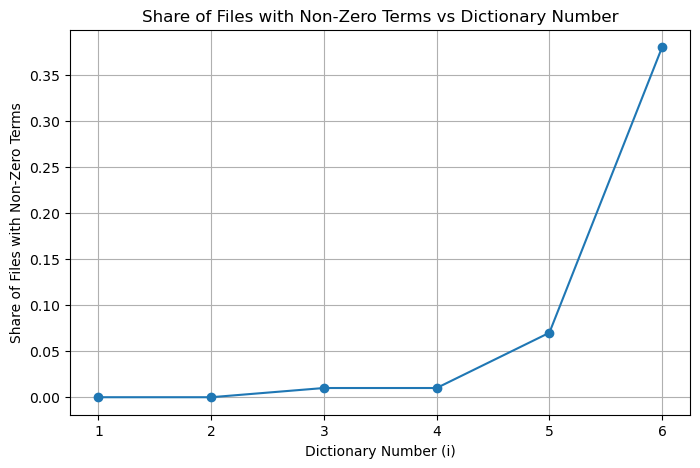

In [310]:
import matplotlib.pyplot as plt

# Prepare lists to store values for plotting
x_values = []  # To store i
y_values = []  # To store share of files with non-zero terms

# Function to evaluate the dictionary and calculate the share of non-zero terms
def evaluate_dict(result_dict, hearing_list):
    non_zero_file_count = 0  # Counter for files with non-zero terms
    
    for file_name, terms in result_dict.items():
        # Filter terms with non-zero relative frequency
        non_zero_terms = [term for term in terms if term['all_rel'] > 0]
        
        if non_zero_terms:  # If there are terms with non-zero frequency
            non_zero_file_count += 1  # Increment the counter

    # Calculate the share of files with non-zero terms
    share_non_zero = round(non_zero_file_count / len(hearing_list), 2)
    return share_non_zero

# Loop to calculate and store data
for i in range(1, 7):
    print(f'Con dictionary number: {i}')
    the_con_dict, all_con_dicts, con_dict_trans = create_dict(i)
    print(f'Length of Con dictionary: {len(the_con_dict)}')
    result_dict = process_hearings(hearing_list)
    
    # Calculate the share of files with non-zero terms
    share = evaluate_dict(result_dict, hearing_list)
    print(f"Share of files with non-zero terms: {share}")
    
    # Append values to lists
    x_values.append(i)
    y_values.append(share)

    print()

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(x_values, y_values, marker='o')
plt.xlabel('Dictionary Number (i)')
plt.ylabel('Share of Files with Non-Zero Terms')
plt.title('Share of Files with Non-Zero Terms vs Dictionary Number')
plt.grid(True)
plt.show()


In [ ]:

# In[8]:

the_cols = ['nw_text_sw', 'text_sw', 'party']
for cnr in cnrs:    
    df = pd.read_csv(project_path("data")+ f"hearing_{cnr}.csv", usecols=the_cols)
    speeches = df.to_dict('records')
    all_nwords = sum(df.nw_text_sw)
    
    print(cnr)
    
    print('Now looking at overall speeches')
    all_terms = []
    counter = 0
    for term in the_con_dict:
        my_dict = {}
        my_dict['term'] = con_dict_trans[term]
        all_total = 0

        for speech in speeches:
            term_count = (' ' + str(speech['text_sw']) + ' ').count(term)
            all_total = all_total + term_count

        my_dict['all_total'] = all_total
        my_dict['all_rel'] = round(all_total / all_nwords * 1000000,3)

        all_terms.append(my_dict)
        counter = counter+1
        if counter % 50 == 0:
            print('%s of %s terms checked.' % (counter, len(the_con_dict)))

    all_terms = sorted(all_terms, key=lambda k: k['diff_sort'], reverse=True)
    for term in all_terms:
        term['diff_rel'] = round(term['diff_rel'] * 1000000,3)
        term.pop('diff_sort')
    '''
    keys = ['term', 'all_total', 'r_total', 'd_total', 'diff_total', 'all_rel', 'r_rel', 'd_rel', 'diff_rel']
    with open("C:/Users/jnyarko/Dropbox/Documents/con_law_project/pfindings/frequencies_cr/overall_" + cnr + ".csv",'wb') as csvfile:
        writer = csv.DictWriter(csvfile, delimiter=',', fieldnames=keys)
        writer.writeheader()
        writer.writerows(all_terms)'''

In [ ]:
# In[23]:

type_df = pd.DataFrame(con_dict_type)
for cnr in cnrs:
    df = pd.read_csv("C:/Users/jnyarko/Dropbox/Documents/con_law_project/pfindings/frequencies_cr/con_" + cnr + ".csv", low_memory=False)
    df = pd.merge(df, pd.DataFrame(con_dict_type), on='term', how='left')
    df.to_csv("C:/Users/jnyarko/Dropbox/Documents/con_law_project/pfindings/frequencies_cr/con_" + cnr + ".csv", index=False)
    
for cnr in cnrs:
    df = pd.read_csv("C:/Users/jnyarko/Dropbox/Documents/con_law_project/pfindings/frequencies_cr/window_" + cnr + ".csv", low_memory=False)
    df = pd.merge(df, pd.DataFrame(con_dict_type), on='term', how='left')
    df.to_csv("C:/Users/jnyarko/Dropbox/Documents/con_law_project/pfindings/frequencies_cr/window_" + cnr + ".csv", index=False)
    
for cnr in cnrs:
    df = pd.read_csv("C:/Users/jnyarko/Dropbox/Documents/con_law_project/pfindings/frequencies_cr/overall_" + cnr + ".csv", low_memory=False)
    df = pd.merge(df, pd.DataFrame(con_dict_type), on='term', how='left')
    df.to_csv("C:/Users/jnyarko/Dropbox/Documents/con_law_project/pfindings/frequencies_cr/overall_" + cnr + ".csv", index=False)


# In[150]:


corrections = {}
corrections['10th amendment'] = ['tenth amendment']
corrections['11th amendment'] = ['eleventh amendment']
corrections['12th amendment'] = ['twelfth amendment']
corrections['13th amendment'] = ['thirteenth amendment']
corrections['14th amendment'] = ['fourteenth amendment']
corrections['15th amendment'] = ['fifteenth amendment']
corrections['16th amendment'] = ['sixteenth amendment']
corrections['17th amendment'] = ['seventeenth amendment']
corrections['18th amendment'] = ['eighteenth amendment']
corrections['19th amendment'] = ['nineteenth amendment']
corrections['1st amendment'] = ['first amendment']
corrections['20th amendment'] = ['twentieth amendment']
corrections['21st amendment'] = ['twenty-first amendment']
corrections['22nd amendment'] = ['twenty-second amendment']
corrections['23rd amendment'] = ['twenty-third amendment']
corrections['24th amendment'] = ['twenty-fourth amendment']
corrections['25th amendment'] = ['twenty-fifth amendment']
corrections['26th amendment'] = ['twenty-sixth amendment']
corrections['27th amendment'] = ['twenty-seventh amendment']
corrections['2nd amendment'] = ['second amendment']
corrections['3/5 clause'] = ['three-fifths clause']
corrections['3/5 compromise'] = ['three-fifths compromise']
corrections['3rd amendment'] = ['third amendment']
corrections['4th amendment'] = ['fourth amendment']
corrections['5th amendment'] = ['fifth amendment']
corrections['6th amendment'] = ['sixth amendment']
corrections['7th amendment'] = ['seventh amendment']
corrections['8th amendment'] = ['eighth amendment']
corrections['9th amendment'] = ['ninth amendment']
corrections['article one'] = ['article i']
corrections['article two'] = ['article ii']
corrections['article three'] = ['article iii']
corrections['article four'] = ['article iv']
corrections['article five'] = ['article v']
corrections['article six'] = ['article vi']
corrections['article seven'] = ['article vii']
corrections['activist judge'] = ['activist judges']
corrections['anti-discrimination'] = ['antidiscrimination']
corrections['anti-federalist'] = ['antifederalist']
corrections['colorblindness'] = ['color blindness']
corrections['commander-in-chief'] = ['commander in chief']
corrections['commander-in-chief clause'] = ['commander in chief clause']
corrections['counter-majoritarian'] = ['countermajoritarian']
corrections['delegation of powers'] = ['delegated powers']
corrections['good behavior clause'] = ['good behaviour clause']
corrections['interstate compact'] = ['interstate compacts']
corrections['provide for the common defense'] = ['provide for the common defence']
corrections['sexual-orientation discrimination'] = ['sexual orientation discrimination']
corrections['void for vagueness'] = ['void-for-vagueness']


# In[147]:


# Combine terms that are spelled differently etc.
for cnr in cnrs:
    df = pd.read_csv("C:/Users/jnyarko/Dropbox/Documents/con_law_project/pfindings/frequencies_cr/con_" + cnr + ".csv", low_memory=False)
    
    df.loc[df['term'] == 'womenÂ’s equality', 'term'] = 'womens equality'
    df.loc[df['term'] == 'womenÂ’s suffrage amendment', 'term'] = 'womens suffrage amendment'
    df.loc[df['term'] == 'statesÂ’ rights', 'term'] = 'states rights'

    for the_key in list(corrections.keys()):
        for e in corrections[the_key]:
            relevant = df.loc[df['term'] == e]
            df.loc[df['term'] == the_key, 'all_total'] = df.loc[df['term'] == the_key, 'all_total'] + relevant['all_total'].iloc[0]
            df.loc[df['term'] == the_key, 'r_total'] = df.loc[df['term'] == the_key, 'r_total'] + relevant['r_total'].iloc[0]
            df.loc[df['term'] == the_key, 'd_total'] = df.loc[df['term'] == the_key, 'd_total'] + relevant['d_total'].iloc[0]
            df.loc[df['term'] == the_key, 'diff_total'] = df.loc[df['term'] == the_key, 'r_total'] - df.loc[df['term'] == the_key, 'd_total']
            df.loc[df['term'] == the_key, 'all_rel'] = df.loc[df['term'] == the_key, 'all_rel'] + relevant['all_rel'].iloc[0]
            df.loc[df['term'] == the_key, 'r_rel'] = df.loc[df['term'] == the_key, 'r_rel'] + relevant['r_rel'].iloc[0]
            df.loc[df['term'] == the_key, 'd_rel'] = df.loc[df['term'] == the_key, 'd_rel'] + relevant['d_rel'].iloc[0]
            df.loc[df['term'] == the_key, 'diff_rel'] = df.loc[df['term'] == the_key, 'r_rel'] - df.loc[df['term'] == the_key, 'd_rel']
    df = df.to_dict('records')
    new_df = []
    duplicates = []
    for obs in df:
        if obs['term'] not in duplicates:
            new_df.append(obs)
            duplicates.append(obs['term'])
    df = pd.DataFrame(new_df)
    df.to_csv("C:/Users/jnyarko/Dropbox/Documents/con_law_project/pfindings/frequencies_cr/con_" + cnr + ".csv", index=False)


# In[148]:


for cnr in cnrs:
    df = pd.read_csv("C:/Users/jnyarko/Dropbox/Documents/con_law_project/pfindings/frequencies_cr/overall_" + cnr + ".csv", low_memory=False)
    
    df.loc[df['term'] == 'womenÂ’s equality', 'term'] = 'womens equality'
    df.loc[df['term'] == 'womenÂ’s suffrage amendment', 'term'] = 'womens suffrage amendment'
    df.loc[df['term'] == 'statesÂ’ rights', 'term'] = 'states rights'

    for the_key in list(corrections.keys()):
        for e in corrections[the_key]:
            relevant = df.loc[df['term'] == e]
            df.loc[df['term'] == the_key, 'all_total'] = df.loc[df['term'] == the_key, 'all_total'] + relevant['all_total'].iloc[0]
            df.loc[df['term'] == the_key, 'r_total'] = df.loc[df['term'] == the_key, 'r_total'] + relevant['r_total'].iloc[0]
            df.loc[df['term'] == the_key, 'd_total'] = df.loc[df['term'] == the_key, 'd_total'] + relevant['d_total'].iloc[0]
            df.loc[df['term'] == the_key, 'diff_total'] = df.loc[df['term'] == the_key, 'r_total'] - df.loc[df['term'] == the_key, 'd_total']
            df.loc[df['term'] == the_key, 'all_rel'] = df.loc[df['term'] == the_key, 'all_rel'] + relevant['all_rel'].iloc[0]
            df.loc[df['term'] == the_key, 'r_rel'] = df.loc[df['term'] == the_key, 'r_rel'] + relevant['r_rel'].iloc[0]
            df.loc[df['term'] == the_key, 'd_rel'] = df.loc[df['term'] == the_key, 'd_rel'] + relevant['d_rel'].iloc[0]
            df.loc[df['term'] == the_key, 'diff_rel'] = df.loc[df['term'] == the_key, 'r_rel'] - df.loc[df['term'] == the_key, 'd_rel']
    df = df.to_dict('records')
    new_df = []
    duplicates = []
    for obs in df:
        if obs['term'] not in duplicates:
            new_df.append(obs)
            duplicates.append(obs['term'])
    df = pd.DataFrame(new_df)
    df.to_csv("C:/Users/jnyarko/Dropbox/Documents/con_law_project/pfindings/frequencies_cr/overall_" + cnr + ".csv", index=False)


# In[149]:


for cnr in cnrs:
    df = pd.read_csv("C:/Users/jnyarko/Dropbox/Documents/con_law_project/pfindings/frequencies_cr/window_" + cnr + ".csv", low_memory=False)
    
    df.loc[df['term'] == 'womenÂ’s equality', 'term'] = 'womens equality'
    df.loc[df['term'] == 'womenÂ’s suffrage amendment', 'term'] = 'womens suffrage amendment'
    df.loc[df['term'] == 'statesÂ’ rights', 'term'] = 'states rights'

    for the_key in list(corrections.keys()):
        for e in corrections[the_key]:
            relevant = df.loc[df['term'] == e]
            df.loc[df['term'] == the_key, 'all_total'] = df.loc[df['term'] == the_key, 'all_total'] + relevant['all_total'].iloc[0]
            df.loc[df['term'] == the_key, 'r_total'] = df.loc[df['term'] == the_key, 'r_total'] + relevant['r_total'].iloc[0]
            df.loc[df['term'] == the_key, 'd_total'] = df.loc[df['term'] == the_key, 'd_total'] + relevant['d_total'].iloc[0]
            df.loc[df['term'] == the_key, 'diff_total'] = df.loc[df['term'] == the_key, 'r_total'] - df.loc[df['term'] == the_key, 'd_total']
            df.loc[df['term'] == the_key, 'all_rel'] = df.loc[df['term'] == the_key, 'all_rel'] + relevant['all_rel'].iloc[0]
            df.loc[df['term'] == the_key, 'r_rel'] = df.loc[df['term'] == the_key, 'r_rel'] + relevant['r_rel'].iloc[0]
            df.loc[df['term'] == the_key, 'd_rel'] = df.loc[df['term'] == the_key, 'd_rel'] + relevant['d_rel'].iloc[0]
            df.loc[df['term'] == the_key, 'diff_rel'] = df.loc[df['term'] == the_key, 'r_rel'] - df.loc[df['term'] == the_key, 'd_rel']
    df = df.to_dict('records')
    new_df = []
    duplicates = []
    for obs in df:
        if obs['term'] not in duplicates:
            new_df.append(obs)
            duplicates.append(obs['term'])
    df = pd.DataFrame(new_df)
    df.to_csv("C:/Users/jnyarko/Dropbox/Documents/con_law_project/pfindings/frequencies_cr/window_" + cnr + ".csv", index=False)


# In[153]:


# Remove the ones that were corrected
all_corrections = []
for the_key in list(corrections.keys()):
    for e in corrections[the_key]:
        all_corrections.append(e)
        
for cnr in cnrs:
    df = pd.read_csv("C:/Users/jnyarko/Dropbox/Documents/con_law_project/pfindings/frequencies_cr/window_" + cnr + ".csv", low_memory=False)
    df = df.to_dict('records')
    new_df = []
    for obs in df:
        if obs['term'] not in all_corrections:
            new_df.append(obs)
    df = pd.DataFrame(new_df)
    df.to_csv("C:/Users/jnyarko/Dropbox/Documents/con_law_project/pfindings/frequencies_cr/window_" + cnr + ".csv", index=False)
    
for cnr in cnrs:
    df = pd.read_csv("C:/Users/jnyarko/Dropbox/Documents/con_law_project/pfindings/frequencies_cr/con_" + cnr + ".csv", low_memory=False)
    df = df.to_dict('records')
    new_df = []
    for obs in df:
        if obs['term'] not in all_corrections:
            new_df.append(obs)
    df = pd.DataFrame(new_df)
    df.to_csv("C:/Users/jnyarko/Dropbox/Documents/con_law_project/pfindings/frequencies_cr/con_" + cnr + ".csv", index=False)
    
    
for cnr in cnrs:
    df = pd.read_csv("C:/Users/jnyarko/Dropbox/Documents/con_law_project/pfindings/frequencies_cr/overall_" + cnr + ".csv", low_memory=False)
    df = df.to_dict('records')
    new_df = []
    for obs in df:
        if obs['term'] not in all_corrections:
            new_df.append(obs)
    df = pd.DataFrame(new_df)
    df.to_csv("C:/Users/jnyarko/Dropbox/Documents/con_law_project/pfindings/frequencies_cr/overall_" + cnr + ".csv", index=False)  
